# Pipeline Experimentations

Notebook structure:
- Cell 1-5: setup and reusable helpers
- Cell 6-9: instrumented pipeline functions and sweep definitions
- Cell 10-12: orchestrator/CVAE sweeps and pipeline reference run
- Cell 13-14: target length challenge (2..12), figures, cleanup

This notebook is pipeline-only: no non-agentic baseline comparison is executed.

In [1]:
import os
import sys
import gc
import math
import json
import random
import time
from pathlib import Path
from typing import Any, Dict, List, Tuple

import numpy as np
import pandas as pd
import torch

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == 'notebooks':
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

DATA_PATH = REPO_ROOT / 'database' / 'training_data.json'
EXPERIMENT_DIR = REPO_ROOT / 'experiments' / 'pipeline_experimentations'
EXPERIMENT_DIR.mkdir(parents=True, exist_ok=True)

RUN_PROFILE = 'fast'  # 'fast' or 'full'
RUN_ORCHESTRATOR_SWEEP = True
RUN_CVAE_SWEEP = True
RUN_LENGTH_SWEEP = True
USE_ESM_BIOLOGIST = True

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
try:
    torch.random.manual_seed(SEED)
except Exception:
    pass

print(f'Repo root: {REPO_ROOT}')
print(f'Data path exists: {DATA_PATH.exists()}')
print(f'CUDA available: {torch.cuda.is_available()}')
print(f'Run profile: {RUN_PROFILE}')

Repo root: /home/arthur/Documents/M2/pfe/multi-expert-peptide-pipeline
Data path exists: True
CUDA available: True
Run profile: fast


In [2]:
from peptide_pipeline.dataloader.dataloader_json import DataLoader as JSONDataLoader
from peptide_pipeline.generator.cvae_generator import CVAEGenerator
from peptide_pipeline.chemist.agent_v1.config_chemist import ChemistConfig, RangeTarget
from peptide_pipeline.chemist.agent_v1.chemist_agent import ChemistAgent
from peptide_pipeline.orchestrator.orchestrator import Orchestrator
from peptide_pipeline.biologist.base import BaseBiologist

TARGET = {
    'dbaasp_id': 'DBAASPS_373',
    'sequence': 'KLFKRWKHLFR',
    'length': 11,
    'ph': None,
    'molecular_weight': 1558.9480000000003,
    'logp': -0.992100000000006,
    'net_charge': 5.0,
    'isoelectric_point': 12.18,
    'hydrophobicity': 1.05,
    'cathionicity': 6,
}

AA = 'ACDEFGHIKLMNPQRSTVWY'
AA_TO_IDX = {aa: i for i, aa in enumerate(AA)}
PAD_IDX = 20
VOCAB_SIZE = 21
MAX_LEN = 14

class FallbackBiologist(BaseBiologist):
    def __init__(self, reference_peptide: str):
        self.reference_peptide = reference_peptide

    def score_peptides(self, peptides: List[str]) -> List[float]:
        if not peptides:
            return []
        ref_set = set(self.reference_peptide)
        denom = max(len(ref_set), 1)
        return [len(ref_set.intersection(set(p))) / denom for p in peptides]

    def predict_activity(self, peptides: List[str], context: Any = None) -> List[float]:
        if isinstance(context, str) and context.strip():
            previous = self.reference_peptide
            self.reference_peptide = context
            scores = self.score_peptides(peptides)
            self.reference_peptide = previous
            return scores
        return self.score_peptides(peptides)


def build_biologist(reference_peptide: str, score_temperature: float = 50.0):
    if USE_ESM_BIOLOGIST:
        try:
            from peptide_pipeline.biologist.esm_biologist_global_l2 import ESMBiologistGlobalL2
            return ESMBiologistGlobalL2(
                reference_peptide=reference_peptide,
                batch_size=16,
                score_temperature=score_temperature,
            )
        except Exception as e:
            print(f'ESM biologist unavailable, using fallback biologist: {e}')
    return FallbackBiologist(reference_peptide=reference_peptide)

/home/arthur/Documents/M2/pfe/multi-expert-peptide-pipeline/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
def encode_one_hot_with_pad(sequences: List[str], max_len: int = MAX_LEN) -> torch.Tensor:
    x = torch.zeros(len(sequences), max_len * VOCAB_SIZE, dtype=torch.float32)
    for i, seq in enumerate(sequences):
        for pos in range(max_len):
            x[i, pos * VOCAB_SIZE + PAD_IDX] = 1.0
        for pos, aa in enumerate(seq[:max_len]):
            if aa in AA_TO_IDX:
                x[i, pos * VOCAB_SIZE + PAD_IDX] = 0.0
                x[i, pos * VOCAB_SIZE + AA_TO_IDX[aa]] = 1.0
    return x


def build_condition_tensor(dataframe: pd.DataFrame, condition_dim: int = 32) -> torch.Tensor:
    cond = torch.zeros(len(dataframe), condition_dim, dtype=torch.float32)
    cond[:, 0] = torch.tensor(dataframe['length'].values, dtype=torch.float32)
    cond[:, 1] = torch.tensor(dataframe['molecular_weight'].values, dtype=torch.float32)
    cond[:, 2] = torch.tensor(dataframe['net_charge'].values, dtype=torch.float32)
    cond[:, 3] = torch.tensor(dataframe['isoelectric_point'].values, dtype=torch.float32)
    cond[:, 4] = torch.tensor(dataframe['hydrophobicity'].values, dtype=torch.float32)
    cond[:, 5] = torch.tensor(dataframe['cathionicity'].values, dtype=torch.float32)
    cond[:, 6] = 0.5
    cond[:, 7] = torch.tensor(dataframe['logp'].values, dtype=torch.float32)
    cond[:, 8] = 0.0
    cond[:, 9] = 5.0
    cond[:, 10] = 5.0
    cond[:, 11] = 100.0
    return cond


loader = JSONDataLoader()
loader.load_data(
    source=str(DATA_PATH),
    columns=[
        'sequence', 'length', 'ph', 'molecular_weight', 'logp',
        'net_charge', 'isoelectric_point', 'hydrophobicity', 'cathionicity'
    ],
    fillna_defaults={
        'length': 10,
        'ph': 7.0,
        'molecular_weight': 1500.0,
        'logp': 0.0,
        'net_charge': 0.0,
        'isoelectric_point': 7.0,
        'hydrophobicity': 0.0,
        'cathionicity': 0.0,
    },
    normalize_sequence=True,
    sequence_column='sequence',
    keep_standard_amino_acids_only=True,
)

df = loader.get_data().copy()
sequences = df['sequence'].tolist()
lengths = torch.tensor(df['length'].astype(int).values, dtype=torch.long)
x = encode_one_hot_with_pad(sequences, max_len=MAX_LEN)
conditions = build_condition_tensor(df, condition_dim=32)

print(f'Dataset rows: {len(df)}')
print(f'x shape: {tuple(x.shape)}')
print(f'conditions shape: {tuple(conditions.shape)}')
display(df.head(3))

Dataset rows: 4410
x shape: (4410, 294)
conditions shape: (4410, 32)


,sequence,length,ph,molecular_weight,logp,net_charge,isoelectric_point,hydrophobicity,cathionicity
0,KVVVKWVVKVVK,12,7.0,1648.291,5.6026,5.0,14.0,-1.07,4
1,LFIFFF,6,7.0,832.059,3.2860,1.0,14.0,-3.25,0
2,KAAAKWAAKAAK,12,7.0,1451.913,1.1499,5.0,14.0,0.33,4


In [4]:
def build_chemist_from_target(
    target: Dict[str, Any],
    width_scale: float = 1.0,
    length_min: float = 8.0,
    length_max: float = 14.0,
    length_weight: float = 1.0,
) -> ChemistAgent:
    ph = 7.0 if target['ph'] is None else float(target['ph'])
    target_length = float(target['length'])
    min_len = min(length_min, target_length)
    max_len = max(length_max, target_length)

    target_mw = float(target['molecular_weight'])
    # Strictness scaling: allow broader range if target is small/large?
    # Keeping original logic for now
    mw_span = max(250.0, 0.35 * target_mw)
    mw_min = max(200.0, target_mw - mw_span)
    mw_max = target_mw + mw_span

    target_charge = float(target['net_charge'])
    charge_span = max(1.5, 0.5 * abs(target_charge))
    charge_min = max(0.0, target_charge - charge_span)
    charge_max = target_charge + charge_span

    target_ip = float(target['isoelectric_point'])
    ip_span = 2.5 * width_scale
    ip_min = max(3.0, target_ip - ip_span)
    ip_max = min(14.0, target_ip + ip_span)

    target_hydro = float(target['hydrophobicity'])
    hydro_span = 1.5 * width_scale
    hydro_min = target_hydro - hydro_span
    hydro_max = target_hydro + hydro_span

    target_logp = float(target['logp'])
    logp_span = 2.0 * width_scale
    logp_min = target_logp - logp_span
    logp_max = target_logp + logp_span

    return ChemistAgent(
        config=ChemistConfig(
            ph=ph,
            length=RangeTarget(min=min_len, max=max_len, target=target_length, weight=length_weight),
            molecular_weight=RangeTarget(min=mw_min, max=mw_max, target=target_mw, weight=1.0),
            logp=RangeTarget(min=logp_min, max=logp_max, target=target_logp, weight=1.0),
            net_charge=RangeTarget(min=charge_min, max=charge_max, target=target_charge, weight=1.0),
            isoelectric_point=RangeTarget(min=ip_min, max=ip_max, target=target_ip, weight=1.0),
            hydrophobicity=RangeTarget(min=hydro_min, max=hydro_max, target=target_hydro, weight=1.0),
        )
    )

def model_cache_path(latent_dim: int, hidden_dim: int, epochs: int, lr: float, kl_anneal_epochs: int = 0) -> Path:
    lr_text = str(lr).replace('.', 'p')
    # Update filename to include KL parameter
    return EXPERIMENT_DIR / f'cvae_lat{latent_dim}_hid{hidden_dim}_ep{epochs}_lr{lr_text}_kl{kl_anneal_epochs}.pth'


def get_or_train_cvae(latent_dim: int, hidden_dim: int, epochs: int, lr: float, kl_anneal_epochs: int, batch_size: int = 64) -> CVAEGenerator:
    # Always include KL in the filename to distinguish configs
    model = CVAEGenerator(max_len=MAX_LEN, latent_dim=latent_dim, hidden_dim=hidden_dim, condition_dim=32)
    path = model_cache_path(latent_dim, hidden_dim, epochs, lr, kl_anneal_epochs)

    if path.exists():
        try:
            model.load_model(str(path))
            print(f"Loaded cached model: {path.name}")
            return model
        except Exception as e:
            print(f"Failed to load cached model {path.name}, retraining. Error: {e}")

    print(f"Training CVAE Model: {path.name} ...")
    device = model.device
    x_local = x.to(device)
    c_local = conditions.to(device)
    l_local = lengths.to(device)

    model.train_model(
        data=x_local,
        conditions=c_local,
        lengths=l_local,
        epochs=epochs,
        batch_size=batch_size,
        lr=lr,
        kl_anneal_epochs=kl_anneal_epochs,
    )
    model.save_model(str(path))
    print(f"Model saved to {path.name}")
    return model

In [5]:
def normalized_hamming(a: str, b: str) -> float:
    m = max(len(a), len(b), 1)
    a_pad = a.ljust(m, '-')
    b_pad = b.ljust(m, '-')
    return sum(ch1 != ch2 for ch1, ch2 in zip(a_pad, b_pad)) / m


def bigram_entropy(peptides: List[str]) -> float:
    counts: Dict[str, int] = {}
    total = 0
    for p in peptides:
        for i in range(max(len(p) - 1, 0)):
            bg = p[i : i + 2]
            counts[bg] = counts.get(bg, 0) + 1
            total += 1
    if total == 0:
        return 0.0
    probs = np.array([v / total for v in counts.values()], dtype=float)
    return float(-(probs * np.log2(np.clip(probs, 1e-12, 1.0))).sum())


def summarize_topk(rows: List[Dict[str, Any]]) -> Dict[str, float]:
    if not rows:
        return {
            'top1_score': 0.0,
            'topk_mean_score': 0.0,
            'validity_rate': 0.0,
            'unique_ratio': 0.0,
            'mean_pairwise_distance': 0.0,
            'bigram_entropy': 0.0,
        }

    peptides = [r['peptide'] for r in rows]
    scores = [float(r.get('combined_score', r.get('score', 0.0))) for r in rows]
    in_limits = [bool(r.get('in_limits', False)) for r in rows]

    dists = []
    for i in range(len(peptides)):
        for j in range(i + 1, len(peptides)):
            dists.append(normalized_hamming(peptides[i], peptides[j]))

    return {
        'top1_score': float(scores[0]),
        'topk_mean_score': float(np.mean(scores)),
        'validity_rate': float(np.mean(in_limits)),
        'unique_ratio': float(len(set(peptides)) / max(len(peptides), 1)),
        'mean_pairwise_distance': float(np.mean(dists) if dists else 0.0),
        'bigram_entropy': bigram_entropy(peptides),
    }

In [6]:
def safe_float(value: Any, default: float = 0.0) -> float:
    try:
        return float(value)
    except (TypeError, ValueError):
        return default


def run_instrumented_pipeline(
    generator: CVAEGenerator,
    chemist: ChemistAgent,
    biologist: BaseBiologist,
    final_target: Dict[str, Any],
    nb_iterations: int,
    nb_peptides: int,
    top_k: int,
    exploration_rate: float,
    random_parent_count: int,
) -> Tuple[List[Dict[str, Any]], pd.DataFrame]:
    orchestrator = Orchestrator(generator=generator, chemist=chemist, biologist=biologist)
    target_constraints = {
        'length': final_target['length'],
        'molecular_weight': final_target['molecular_weight'],
        'logp': final_target['logp'],
        'net_charge': final_target['net_charge'],
        'isoelectric_point': final_target['isoelectric_point'],
        'hydrophobicity': final_target['hydrophobicity'],
        'cathionicity': final_target['cathionicity'],
    }

    top_rows = orchestrator.run(
        nb_iterations=nb_iterations,
        nb_peptides=nb_peptides,
        top_k=top_k,
        exploration_rate=exploration_rate,
        initial_peptide=final_target['sequence'],
        final_target=target_constraints,
        random_parent_count=random_parent_count,
    )

    # Reconstruct compact iteration trace from returned rows.
    trace_rows: List[Dict[str, Any]] = []
    if top_rows:
        by_iter = pd.DataFrame(top_rows).groupby('iteration', as_index=False)
        for _, chunk in by_iter:
            trace_rows.append(
                {
                    'iteration': int(chunk['iteration'].iloc[0]),
                    'returned_count': int(len(chunk)),
                    'best_combined_score': float(chunk['combined_score'].max()),
                    'mean_combined_score': float(chunk['combined_score'].mean()),
                    'validity_rate_returned': float(chunk['in_limits'].astype(float).mean()),
                }
            )

    return top_rows, pd.DataFrame(trace_rows).sort_values('iteration').reset_index(drop=True)


def run_non_agentic_baseline(
    generator: CVAEGenerator,
    chemist: ChemistAgent,
    biologist: BaseBiologist,
    final_target: Dict[str, Any],
    budget: int,
    top_k: int,
) -> List[Dict[str, Any]]:
    constraints = {
        'length': final_target['length'],
        'molecular_weight': final_target['molecular_weight'],
        'logp': final_target['logp'],
        'net_charge': final_target['net_charge'],
        'isoelectric_point': final_target['isoelectric_point'],
        'hydrophobicity': final_target['hydrophobicity'],
        'cathionicity': final_target['cathionicity'],
    }

    peptides = generator.generate_peptides(count=budget, constraints=constraints)
    chem_rows = chemist.evaluate_peptides(peptides)
    valid_rows = [r for r in chem_rows if r.get('sequence')]
    bio_scores = biologist.score_peptides([r['sequence'] for r in valid_rows])

    rows = []
    for c_row, b_score in zip(valid_rows, bio_scores):
        chem_score = safe_float(c_row.get('score', 0.0))
        bio_score = safe_float(b_score)
        combined = 0.5 * (chem_score + bio_score)
        rows.append(
            {
                'peptide': c_row['sequence'],
                'score': combined,
                'combined_score': combined,
                'chemist_score': chem_score,
                'biologist_score': bio_score,
                'in_limits': bool(c_row.get('in_limits', False)),
                'properties': c_row.get('properties', {}),
                'iteration': 1,
            }
        )

    rows = sorted(
        rows,
        key=lambda x: (x['in_limits'], x['combined_score'], x['biologist_score'], x['chemist_score']),
        reverse=True,
    )
    dedup = {}
    for row in rows:
        if row['peptide'] not in dedup:
            dedup[row['peptide']] = row
    return list(dedup.values())[:top_k]

In [7]:
# Definition of Baseline and Sweeps
# We establish a strong baseline, then vary parameters one by one to isolate effects.

BASELINE_ORCHESTRATOR = {
    'nb_iterations': 20,
    'nb_peptides': 128,
    'top_k': 10,
    'exploration_rate': 0.1,
    'random_parent_count': 4
} # A balanced starting point

BASELINE_CVAE = {
    'latent_dim': 64,
    'hidden_dim': 256,
    'epochs': 120,
    'lr': 0.001,
    'kl_anneal_epochs': 40
}

# Parameters to sweep. Keys match the config dict keys.
# We will generate a list of configs where only one parameter deviates from BASELINE.
ORCHESTRATOR_VARIANTS = {
    'nb_iterations': [5, 10, 30, 50],
    'nb_peptides': [64, 256, 512],
    'top_k': [5, 20, 50],
    'exploration_rate': [0.0, 0.2, 0.4, 0.6],
    'random_parent_count': [0, 10, 20]
}

CVAE_VARIANTS = {
    'latent_dim': [32, 128],
    'hidden_dim': [128, 512],
    'epochs': [60, 200],
    'kl_anneal_epochs': [10, 80]
}

# Rigorous repeats settings
if RUN_PROFILE == 'fast':
    REPEATS = 2
else:
    REPEATS = 10  # More rigorous statistical representation (10+ runs per point)

print(f"Run Profile: {RUN_PROFILE}")
print(f"Repeats per experiment: {REPEATS}")
print(f"Baseline Orchestrator: {BASELINE_ORCHESTRATOR}")
print(f"Baseline CVAE: {BASELINE_CVAE}")

Run Profile: fast
Repeats per experiment: 2
Baseline Orchestrator: {'nb_iterations': 20, 'nb_peptides': 128, 'top_k': 10, 'exploration_rate': 0.1, 'random_parent_count': 4}
Baseline CVAE: {'latent_dim': 64, 'hidden_dim': 256, 'epochs': 120, 'lr': 0.001, 'kl_anneal_epochs': 40}


In [8]:
orchestrator_records = []
orchestrator_traces = []

if RUN_ORCHESTRATOR_SWEEP:
    # 1. Train the reference CVAE model (Baseline config) once.
    print("Training CVAE Baseline for Orchestrator Sweep...")
    fixed_model = get_or_train_cvae(**BASELINE_CVAE)

    # 2. Reuse a single biologist across all orchestrator configs.
    biologist = build_biologist(TARGET['sequence'], score_temperature=50.0)

    # 3. Prepare experiment list (Baseline + One-At-A-Time Variations)
    experiment_tasks = []

    # Baseline Task
    experiment_tasks.append({
        'name': 'Baseline',
        'params': BASELINE_ORCHESTRATOR.copy(),
        'param_name': 'baseline',
        'param_value': 'baseline'
    })

    # Variant Tasks
    for param_key, variants in ORCHESTRATOR_VARIANTS.items():
        for val in variants:
            cfg = BASELINE_ORCHESTRATOR.copy()
            cfg[param_key] = val
            experiment_tasks.append({
                'name': f"{param_key}={val}",
                'params': cfg,
                'param_name': param_key,
                'param_value': val
            })

    print(f"Total Orchestrator Configurations to run: {len(experiment_tasks)}")

    # 4. Execute Tasks
    for i, task in enumerate(experiment_tasks, start=1):
        run_cfg = task['params']
        param_name = task['param_name']
        param_val = task['param_value']

        per_cfg_metrics = []
        per_cfg_times = []
        total_generated = int(run_cfg['nb_iterations'] * run_cfg['nb_peptides'])

        print(f"Processing config {i}/{len(experiment_tasks)}: {task['name']} (Repeats: {REPEATS})")

        for rep in range(1, REPEATS + 1):
            # Seed strategy: Base seed + Config Index + Repeat Index to ensure reproducibility but variance
            seed_val = SEED + 10_000 + (100 * i) + rep
            random.seed(seed_val)
            np.random.seed(seed_val)
            try:
                torch.random.manual_seed(seed_val)
            except Exception:
                pass

            chemist = build_chemist_from_target(TARGET)

            run_start = time.perf_counter()
            top_rows, trace_df = run_instrumented_pipeline(
                generator=fixed_model,
                chemist=chemist,
                biologist=biologist,
                final_target=TARGET,
                nb_iterations=run_cfg['nb_iterations'],
                nb_peptides=run_cfg['nb_peptides'],
                top_k=run_cfg['top_k'],
                exploration_rate=run_cfg['exploration_rate'],
                random_parent_count=run_cfg['random_parent_count'],
            )
            elapsed_sec = float(time.perf_counter() - run_start)

            metrics = summarize_topk(top_rows)
            per_cfg_metrics.append(metrics)
            per_cfg_times.append(elapsed_sec)

            orchestrator_records.append(
                {
                    'config_name': task['name'],
                    'param_name': param_name,
                    'param_value': param_val,
                    'repeat': rep,
                    'total_generated': total_generated,
                    'elapsed_sec': elapsed_sec,
                    **run_cfg,  # Log all parameters
                    **metrics,
                }
            )

            if not trace_df.empty:
                trace_df = trace_df.copy()
                trace_df['config_name'] = task['name']
                trace_df['repeat'] = rep
                trace_df['elapsed_sec'] = elapsed_sec
                orchestrator_traces.append(trace_df)

        top1_vals = [m['top1_score'] for m in per_cfg_metrics]
        mean_top1 = np.mean(top1_vals)
        std_top1 = np.std(top1_vals, ddof=1) if len(top1_vals) > 1 else 0.0
        mean_time = np.mean(per_cfg_times) if per_cfg_times else 0.0
        std_time = np.std(per_cfg_times, ddof=1) if len(per_cfg_times) > 1 else 0.0
        print(f"  -> Finished: top1={mean_top1:.4f} ± {std_top1:.4f} | time={mean_time:.2f}s ± {std_time:.2f}s")

orchestrator_raw_df = pd.DataFrame(orchestrator_records)
orchestrator_trace_df = pd.concat(orchestrator_traces, ignore_index=True) if orchestrator_traces else pd.DataFrame()
orchestrator_results_df = pd.DataFrame()

if not orchestrator_raw_df.empty:
    # Group by the specific variation parameter
    orchestrator_results_df = orchestrator_raw_df.groupby(
        ['config_name', 'param_name', 'param_value'],
        as_index=False,
    ).agg({
        'top1_score': ['mean', 'std'],
        'topk_mean_score': ['mean', 'std'],
        'validity_rate': ['mean', 'std'],
        'unique_ratio': ['mean', 'std'],
        'mean_pairwise_distance': ['mean', 'std'],
        'elapsed_sec': ['mean', 'std'],
        'total_generated': 'first'
    })
    orchestrator_results_df.columns = ['_'.join(c).strip('_') for c in orchestrator_results_df.columns]
    orchestrator_results_df = orchestrator_results_df.sort_values(
        ['top1_score_mean', 'validity_rate_mean'],
        ascending=[False, False],
    ).reset_index(drop=True)

display(orchestrator_results_df)
display(orchestrator_raw_df.head(10))

Training CVAE Baseline for Orchestrator Sweep...
Loaded cached model: cvae_lat64_hid256_ep120_lr0p001_kl40.pth


Loading weights: 100%|██████████| 209/209 [00:00<00:00, 1541.83it/s, Materializing param=encoder.layer.11.output.dense.weight]                      
EsmModel LOAD REPORT from: facebook/esm2_t12_35M_UR50D
Key                         | Status     | 
----------------------------+------------+-
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total Orchestrator Configurations to run: 18
Processing config 1/18: Baseline (Repeats: 2)
  -> Finished: top1=0.8856 ± 0.0005 | time=3.57s ± 0.01s
Processing config 2/18: nb_iterations=5 (Repeats: 2)
  -> Finished: top1=0.8760 ± 0.0013 | time=0.90s ± 0.01s
Processing config 3/18: nb_iterations=10 (Repeats: 2)
  -> Finished: top1=0.8824 ± 0.0016 | time=1.77s ± 0.04s
Processing config 4/18: nb_iterations=30 (Repeats: 2)
  -> Finished: top1=0.8849 ± 0.0057 | time=5.28s ± 0.00s
Processing config 5/18: nb_iterations=50 (Repeats: 2)
  -> Finished: top1=0.8888 ± 0.0007 | time=8.82s ± 0.16s
Processing config 6/18: nb_peptides=64 (Repeats: 2)
  -> Finished: top1=0.8783 ± 0.0033 | time=1.90s ± 0.05s
Processing config 7/18: nb_peptides=256 (Repeats: 2)
  -> Finished: top1=0.8865 ± 0.0013 | time=7.19s ± 0.09s
Processing config 8/18: nb_peptides=512 (Repeats: 2)
  -> Finished: top1=0.8899 ± 0.0039 | time=14.29s ± 0.07s
Processing config 9/18: top_k=5 (Repeats: 2)
  -> Finished: top1=0.8851 ± 0.000

,config_name,param_name,param_value,top1_score_mean,top1_score_std,topk_mean_score_mean,topk_mean_score_std,validity_rate_mean,validity_rate_std,unique_ratio_mean,unique_ratio_std,mean_pairwise_distance_mean,mean_pairwise_distance_std,elapsed_sec_mean,elapsed_sec_std,total_generated_first
0,nb_peptides=512,nb_peptides,512,0.889903,0.003879,0.884822,0.000936,1.0,0.0,1.0,0.0,0.677778,0.084281,14.286489,0.065810,10240
1,nb_iterations=50,nb_iterations,50,0.888831,0.000668,0.884856,0.000611,1.0,0.0,1.0,0.0,0.632323,0.045712,8.818805,0.162139,6400
2,random_parent_count=20,random_parent_count,20,0.887985,0.002963,0.880640,0.000548,1.0,0.0,1.0,0.0,0.694949,0.045712,3.573794,0.012492,2560
3,top_k=20,top_k,20,0.887562,0.006193,0.877811,0.001187,1.0,0.0,1.0,0.0,0.708373,0.022668,3.552443,0.087508,2560
4,top_k=50,top_k,50,0.887376,0.001030,0.872332,0.002572,1.0,0.0,1.0,0.0,0.723859,0.029176,3.703729,0.031258,2560
5,nb_peptides=256,nb_peptides,256,0.886452,0.001327,0.881722,0.001678,1.0,0.0,1.0,0.0,0.720202,0.075710,7.185178,0.089415,5120
6,Baseline,baseline,baseline,0.885600,0.000493,0.877732,0.002889,1.0,0.0,1.0,0.0,0.716162,0.032855,3.571803,0.014930,2560
7,top_k=5,top_k,5,0.885105,0.000217,0.883100,0.000502,1.0,0.0,1.0,0.0,0.577273,0.173563,3.482528,0.084992,2560
8,nb_iterations=30,nb_iterations,30,0.884924,0.005690,0.878868,0.002026,1.0,0.0,1.0,0.0,0.739394,0.019999,5.276203,0.001741,3840
9,random_parent_count=10,random_parent_count,10,0.884538,0.004432,0.875852,0.002541,1.0,0.0,1.0,0.0,0.719192,0.008571,3.486114,0.036008,2560


,config_name,param_name,param_value,repeat,total_generated,elapsed_sec,nb_iterations,nb_peptides,top_k,exploration_rate,random_parent_count,top1_score,topk_mean_score,validity_rate,unique_ratio,mean_pairwise_distance,bigram_entropy
0,Baseline,baseline,baseline,1,2560,3.561246,20,128,10,0.1,4,0.885949,0.879775,1.0,1.0,0.739394,4.921335
1,Baseline,baseline,baseline,2,2560,3.582360,20,128,10,0.1,4,0.885252,0.875690,1.0,1.0,0.692929,4.808724
2,nb_iterations=5,nb_iterations,5,1,640,0.894648,5,128,10,0.1,4,0.876928,0.871278,1.0,1.0,0.656566,4.750463
3,nb_iterations=5,nb_iterations,5,2,640,0.903089,5,128,10,0.1,4,0.875085,0.867557,1.0,1.0,0.822222,4.872342
4,nb_iterations=10,nb_iterations,10,1,1280,1.740262,10,128,10,0.1,4,0.881235,0.874442,1.0,1.0,0.787879,4.952271
5,nb_iterations=10,nb_iterations,10,2,1280,1.793770,10,128,10,0.1,4,0.883539,0.875080,1.0,1.0,0.791919,4.928144
6,nb_iterations=30,nb_iterations,30,1,3840,5.277434,30,128,10,0.1,4,0.880900,0.877435,1.0,1.0,0.753535,4.879429
7,nb_iterations=30,nb_iterations,30,2,3840,5.274971,30,128,10,0.1,4,0.888947,0.880301,1.0,1.0,0.725253,4.429955
8,nb_iterations=50,nb_iterations,50,1,6400,8.704156,50,128,10,0.1,4,0.888358,0.884424,1.0,1.0,0.664646,4.460567
9,nb_iterations=50,nb_iterations,50,2,6400,8.933455,50,128,10,0.1,4,0.889303,0.885288,1.0,1.0,0.600000,4.521106


In [9]:
cvae_records = []

if RUN_CVAE_SWEEP:
    # Use Baseline Orchestrator settings for CVAE comparison
    orch_config = BASELINE_ORCHESTRATOR
    biologist = build_biologist(TARGET['sequence'], score_temperature=50.0)

    # 1. Prepare experiment list (Baseline + One-At-A-Time Variations)
    cvae_tasks = []

    # Baseline Task
    cvae_tasks.append({
        'name': 'Baseline',
        'params': BASELINE_CVAE.copy(),
        'param_name': 'baseline',
        'param_value': 'baseline'
    })

    # Variant Tasks
    for param_key, variants in CVAE_VARIANTS.items():
        for val in variants:
            cfg = BASELINE_CVAE.copy()
            cfg[param_key] = val
            cvae_tasks.append({
                'name': f"{param_key}={val}",
                'params': cfg,
                'param_name': param_key,
                'param_value': val
            })

    print(f"Total CVAE Configurations to run: {len(cvae_tasks)}")

    # 2. Execute CVAE Tasks
    for i, task in enumerate(cvae_tasks, start=1):
        cvae_cfg = task['params']
        param_name = task['param_name']
        print(f"Processing CVAE config {i}/{len(cvae_tasks)}: {task['name']} (Repeats: {REPEATS})")

        per_cfg_metrics = []
        per_cfg_times = []

        for rep in range(1, REPEATS + 1):
            seed_val = SEED + 20_000 + (100 * i) + rep
            random.seed(seed_val)
            np.random.seed(seed_val)
            try:
                torch.random.manual_seed(seed_val)
            except Exception:
                pass

            # Train/load model for this specific config (not timed inside run).
            model = get_or_train_cvae(**cvae_cfg)
            chemist = build_chemist_from_target(TARGET)

            run_start = time.perf_counter()
            top_rows, trace_df = run_instrumented_pipeline(
                generator=model,
                chemist=chemist,
                biologist=biologist,
                final_target=TARGET,
                nb_iterations=orch_config['nb_iterations'],
                nb_peptides=orch_config['nb_peptides'],
                top_k=orch_config['top_k'],
                exploration_rate=orch_config['exploration_rate'],
                random_parent_count=orch_config['random_parent_count'],
            )
            elapsed_sec = float(time.perf_counter() - run_start)

            metrics = summarize_topk(top_rows)
            per_cfg_metrics.append(metrics)
            per_cfg_times.append(elapsed_sec)

            cvae_records.append({
                'config_name': task['name'],
                'param_name': param_name,
                'param_value': task['param_value'],
                'repeat': rep,
                'elapsed_sec': elapsed_sec,
                **cvae_cfg,
                **metrics
            })

            print(f"  > Rep {rep}: top1={metrics['top1_score']:.3f} val_rate={metrics['validity_rate']:.2f} time={elapsed_sec:.2f}s")

        top1_vals = [m['top1_score'] for m in per_cfg_metrics]
        mean_top1 = np.mean(top1_vals)
        std_top1 = np.std(top1_vals, ddof=1) if len(top1_vals) > 1 else 0.0
        mean_time = np.mean(per_cfg_times) if per_cfg_times else 0.0
        std_time = np.std(per_cfg_times, ddof=1) if len(per_cfg_times) > 1 else 0.0
        print(f"  -> Finished {task['name']}: top1={mean_top1:.4f} ± {std_top1:.4f} | time={mean_time:.2f}s ± {std_time:.2f}s")

cvae_raw_df = pd.DataFrame(cvae_records)
cvae_results_df = pd.DataFrame()

if not cvae_raw_df.empty:
    cvae_results_df = cvae_raw_df.groupby(
        ['config_name', 'param_name', 'param_value'],
        as_index=False,
    ).agg({
        'top1_score': ['mean', 'std'],
        'topk_mean_score': ['mean', 'std'],
        'validity_rate': ['mean', 'std'],
        'unique_ratio': ['mean', 'std'],
        'mean_pairwise_distance': ['mean', 'std'],
        'elapsed_sec': ['mean', 'std'],
        'latent_dim': 'first',
        'hidden_dim': 'first',
        'epochs': 'first'
    })
    cvae_results_df.columns = ['_'.join(c).strip('_') for c in cvae_results_df.columns]
    cvae_results_df = cvae_results_df.sort_values(
        ['top1_score_mean', 'validity_rate_mean', 'mean_pairwise_distance_mean'],
        ascending=[False, False, False],
    ).reset_index(drop=True)

display(cvae_results_df)
display(cvae_raw_df.head(10))

Loading weights: 100%|██████████| 209/209 [00:00<00:00, 1524.67it/s, Materializing param=encoder.layer.11.output.dense.weight]                      
EsmModel LOAD REPORT from: facebook/esm2_t12_35M_UR50D
Key                         | Status     | 
----------------------------+------------+-
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total CVAE Configurations to run: 9
Processing CVAE config 1/9: Baseline (Repeats: 2)
Loaded cached model: cvae_lat64_hid256_ep120_lr0p001_kl40.pth
  > Rep 1: top1=0.884 val_rate=1.00 time=3.51s
Loaded cached model: cvae_lat64_hid256_ep120_lr0p001_kl40.pth
  > Rep 2: top1=0.884 val_rate=1.00 time=3.47s
  -> Finished Baseline: top1=0.8840 ± 0.0006 | time=3.49s ± 0.03s
Processing CVAE config 2/9: latent_dim=32 (Repeats: 2)
Loaded cached model: cvae_lat32_hid256_ep120_lr0p001_kl40.pth
  > Rep 1: top1=0.889 val_rate=1.00 time=3.52s
Loaded cached model: cvae_lat32_hid256_ep120_lr0p001_kl40.pth
  > Rep 2: top1=0.884 val_rate=1.00 time=3.49s
  -> Finished latent_dim=32: top1=0.8865 ± 0.0033 | time=3.50s ± 0.02s
Processing CVAE config 3/9: latent_dim=128 (Repeats: 2)
Loaded cached model: cvae_lat128_hid256_ep120_lr0p001_kl40.pth
  > Rep 1: top1=0.881 val_rate=1.00 time=3.49s
Loaded cached model: cvae_lat128_hid256_ep120_lr0p001_kl40.pth
  > Rep 2: top1=0.878 val_rate=1.00 time=3.52s
  -> Finis

,config_name,param_name,param_value,top1_score_mean,top1_score_std,topk_mean_score_mean,topk_mean_score_std,validity_rate_mean,validity_rate_std,unique_ratio_mean,unique_ratio_std,mean_pairwise_distance_mean,mean_pairwise_distance_std,elapsed_sec_mean,elapsed_sec_std,latent_dim_first,hidden_dim_first,epochs_first
0,kl_anneal_epochs=10,kl_anneal_epochs,10,0.888213,0.001859,0.881730,0.000128,1.0,0.0,1.0,0.0,0.722222,0.064282,3.481001,0.062513,64,256,120
1,hidden_dim=512,hidden_dim,512,0.887914,0.012153,0.881299,0.005005,1.0,0.0,1.0,0.0,0.716162,0.041426,3.588247,0.011638,64,512,120
2,latent_dim=32,latent_dim,32,0.886535,0.003319,0.881272,0.001862,1.0,0.0,1.0,0.0,0.714141,0.078567,3.504601,0.018398,32,256,120
3,kl_anneal_epochs=80,kl_anneal_epochs,80,0.885537,0.004173,0.878106,0.002806,1.0,0.0,1.0,0.0,0.707071,0.028570,3.698130,0.031636,64,256,120
4,Baseline,baseline,baseline,0.884009,0.000600,0.877453,0.002247,1.0,0.0,1.0,0.0,0.702020,0.007142,3.491006,0.031697,64,256,120
5,hidden_dim=128,hidden_dim,128,0.882731,0.002888,0.877381,0.000147,1.0,0.0,1.0,0.0,0.718182,0.021427,3.567600,0.063855,64,128,120
6,epochs=60,epochs,60,0.881251,0.001613,0.873195,0.000765,1.0,0.0,1.0,0.0,0.725253,0.019999,3.420109,0.011819,64,256,60
7,epochs=200,epochs,200,0.880733,0.000661,0.877267,0.001079,1.0,0.0,1.0,0.0,0.716162,0.007142,3.628194,0.011046,64,256,200
8,latent_dim=128,latent_dim,128,0.879647,0.001680,0.874525,0.000510,1.0,0.0,1.0,0.0,0.736364,0.058568,3.502298,0.021814,128,256,120


,config_name,param_name,param_value,repeat,elapsed_sec,latent_dim,hidden_dim,epochs,lr,kl_anneal_epochs,top1_score,topk_mean_score,validity_rate,unique_ratio,mean_pairwise_distance,bigram_entropy
0,Baseline,baseline,baseline,1,3.513420,64,256,120,0.001,40,0.883585,0.879042,1.0,1.0,0.696970,4.781335
1,Baseline,baseline,baseline,2,3.468593,64,256,120,0.001,40,0.884434,0.875865,1.0,1.0,0.707071,4.831531
2,latent_dim=32,latent_dim,32,1,3.517610,32,256,120,0.001,40,0.888882,0.882588,1.0,1.0,0.658586,4.540337
3,latent_dim=32,latent_dim,32,2,3.491591,32,256,120,0.001,40,0.884188,0.879955,1.0,1.0,0.769697,4.809953
4,latent_dim=128,latent_dim,128,1,3.486873,128,256,120,0.001,40,0.880835,0.874164,1.0,1.0,0.777778,4.738732
5,latent_dim=128,latent_dim,128,2,3.517723,128,256,120,0.001,40,0.878459,0.874886,1.0,1.0,0.694949,4.806210
6,hidden_dim=128,hidden_dim,128,1,3.522448,64,128,120,0.001,40,0.884774,0.877277,1.0,1.0,0.703030,4.859080
7,hidden_dim=128,hidden_dim,128,2,3.612752,64,128,120,0.001,40,0.880689,0.877485,1.0,1.0,0.733333,4.904562
8,hidden_dim=512,hidden_dim,512,1,3.596477,64,512,120,0.001,40,0.896507,0.884838,1.0,1.0,0.745455,4.835693
9,hidden_dim=512,hidden_dim,512,2,3.580018,64,512,120,0.001,40,0.879321,0.877760,1.0,1.0,0.686869,4.962076


In [10]:
pipeline_reference_rows = []

# Pipeline-only reference run using the best CVAE found in the sweep.
if 'cvae_results_df' in globals() and not cvae_results_df.empty:
    best_row = cvae_results_df.iloc[0]
    best_cvae_cfg = {
        'latent_dim': int(best_row['latent_dim_first']),
        'hidden_dim': int(best_row['hidden_dim_first']),
        'epochs': int(best_row['epochs_first']),
        'lr': BASELINE_CVAE['lr'],
        'kl_anneal_epochs': BASELINE_CVAE['kl_anneal_epochs'],
    }
    print(f"Using best CVAE config from sweep: {best_cvae_cfg}")
else:
    best_cvae_cfg = BASELINE_CVAE
    print(f"No CVAE sweep results found. Using baseline CVAE: {best_cvae_cfg}")

chosen_model = get_or_train_cvae(**best_cvae_cfg)

base_orch = BASELINE_ORCHESTRATOR
biologist = build_biologist(TARGET['sequence'], score_temperature=50.0)

print(f"Running pipeline reference repeats: {REPEATS}")

for rep in range(1, REPEATS + 1):
    random.seed(SEED + 30_000 + rep)
    np.random.seed(SEED + 30_000 + rep)
    try:
        torch.random.manual_seed(SEED + 30_000 + rep)
    except Exception:
        pass

    chemist = build_chemist_from_target(TARGET)

    run_start = time.perf_counter()
    pipe_rows, _ = run_instrumented_pipeline(
        generator=chosen_model,
        chemist=chemist,
        biologist=biologist,
        final_target=TARGET,
        nb_iterations=base_orch['nb_iterations'],
        nb_peptides=base_orch['nb_peptides'],
        top_k=base_orch['top_k'],
        exploration_rate=base_orch['exploration_rate'],
        random_parent_count=base_orch['random_parent_count'],
    )
    elapsed_sec = float(time.perf_counter() - run_start)

    pipe_metrics = summarize_topk(pipe_rows)
    pipeline_reference_rows.append({'repeat': rep, 'method': 'pipeline_reference', 'elapsed_sec': elapsed_sec, **pipe_metrics})

pipeline_reference_df = pd.DataFrame(pipeline_reference_rows)
pipeline_reference_summary_df = pd.DataFrame()
if not pipeline_reference_df.empty:
    pipeline_reference_summary_df = pipeline_reference_df.groupby('method', as_index=False).agg({
        'top1_score': ['mean', 'std'],
        'topk_mean_score': ['mean', 'std'],
        'validity_rate': ['mean', 'std'],
        'unique_ratio': ['mean', 'std'],
        'mean_pairwise_distance': ['mean', 'std'],
        'bigram_entropy': ['mean', 'std'],
        'elapsed_sec': ['mean', 'std'],
    })
    pipeline_reference_summary_df.columns = ['_'.join(col).strip('_') for col in pipeline_reference_summary_df.columns.values]

display(pipeline_reference_summary_df)
display(pipeline_reference_df.head(10))

Using best CVAE config from sweep: {'latent_dim': 64, 'hidden_dim': 256, 'epochs': 120, 'lr': 0.001, 'kl_anneal_epochs': 40}
Loaded cached model: cvae_lat64_hid256_ep120_lr0p001_kl40.pth


Loading weights: 100%|██████████| 209/209 [00:00<00:00, 1533.14it/s, Materializing param=encoder.layer.11.output.dense.weight]                      
EsmModel LOAD REPORT from: facebook/esm2_t12_35M_UR50D
Key                         | Status     | 
----------------------------+------------+-
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Running pipeline reference repeats: 2


,method,top1_score_mean,top1_score_std,topk_mean_score_mean,topk_mean_score_std,validity_rate_mean,validity_rate_std,unique_ratio_mean,unique_ratio_std,mean_pairwise_distance_mean,mean_pairwise_distance_std,bigram_entropy_mean,bigram_entropy_std,elapsed_sec_mean,elapsed_sec_std
0,pipeline_reference,0.881329,0.004459,0.876514,0.003947,1.0,0.0,1.0,0.0,0.769697,0.011428,4.832624,0.098911,3.694326,0.048908


,repeat,method,elapsed_sec,top1_score,topk_mean_score,validity_rate,unique_ratio,mean_pairwise_distance,bigram_entropy
0,1,pipeline_reference,3.659743,0.878176,0.873723,1.0,1.0,0.777778,4.902565
1,2,pipeline_reference,3.728909,0.884482,0.879306,1.0,1.0,0.761616,4.762683


In [11]:
# Length-compression study: can we keep quality with shorter target peptides?
length_sweep_rows = []

if RUN_LENGTH_SWEEP:
    # Use the baseline CVAE model for a controlled length sweep.
    chosen_model = get_or_train_cvae(**BASELINE_CVAE)

    base_run = BASELINE_ORCHESTRATOR

    # Target lengths: 2 to 12 as requested.
    length_candidates = list(range(2, 13))

    biologist_len = build_biologist(TARGET['sequence'], score_temperature=50.0)
    original_len = float(TARGET['length'])

    print(f"Running length sweep on lengths: {length_candidates}")

    for target_len in length_candidates:
        ratio = float(target_len) / max(original_len, 1.0)
        compressed_target = dict(TARGET)
        compressed_target['length'] = int(target_len)

        # Scale length-dependent target properties so short targets remain feasible.
        compressed_target['molecular_weight'] = float(TARGET['molecular_weight']) * ratio
        compressed_target['net_charge'] = max(1.0, float(TARGET['net_charge']) * ratio)

        width_scale = 1.0 + (0.5 if target_len < 5 else (0.2 if target_len < TARGET['length'] else 0.0))
        min_allowed = max(2.0, float(target_len) - 1.0)
        max_allowed = min(float(MAX_LEN), float(target_len) + 1.0)

        chemist_len = build_chemist_from_target(
            compressed_target,
            width_scale=width_scale,
            length_min=min_allowed,
            length_max=max_allowed,
            length_weight=1.5,
        )

        for rep in range(1, REPEATS + 1):
            random.seed(SEED + 40_000 + (100 * target_len) + rep)
            np.random.seed(SEED + 40_000 + (100 * target_len) + rep)
            try:
                torch.random.manual_seed(SEED + 40_000 + (100 * target_len) + rep)
            except Exception:
                pass

            run_start = time.perf_counter()
            top_rows, _ = run_instrumented_pipeline(
                generator=chosen_model,
                chemist=chemist_len,
                biologist=biologist_len,
                final_target=compressed_target,
                nb_iterations=base_run['nb_iterations'],
                nb_peptides=base_run['nb_peptides'],
                top_k=base_run['top_k'],
                exploration_rate=base_run['exploration_rate'],
                random_parent_count=base_run['random_parent_count'],
            )
            elapsed_sec = float(time.perf_counter() - run_start)

            metrics = summarize_topk(top_rows)
            realized_lengths = [
                float(r.get('properties', {}).get('length', len(r.get('peptide', ''))))
                for r in top_rows
            ]
            mean_realized_len = float(np.mean(realized_lengths)) if realized_lengths else 0.0

            length_sweep_rows.append(
                {
                    'target_length': int(target_len),
                    'repeat': rep,
                    'elapsed_sec': elapsed_sec,
                    'mean_realized_length': mean_realized_len,
                    'top1_score': metrics['top1_score'],
                    'topk_mean_score': metrics['topk_mean_score'],
                    'validity_rate': metrics['validity_rate'],
                    'mean_pairwise_distance': metrics['mean_pairwise_distance'],
                }
            )

        current_rows = [r for r in length_sweep_rows if r['target_length'] == target_len]
        avg_top1 = np.mean([r['top1_score'] for r in current_rows])
        avg_time = np.mean([r['elapsed_sec'] for r in current_rows])
        print(f"  Length {target_len}: top1={avg_top1:.3f} | time={avg_time:.2f}s")

length_sweep_df = pd.DataFrame(length_sweep_rows)
length_sweep_summary_df = pd.DataFrame()

if not length_sweep_df.empty:
    length_sweep_summary_df = length_sweep_df.groupby('target_length', as_index=False).agg({
        'mean_realized_length': ['mean', 'std'],
        'top1_score': ['mean', 'std'],
        'topk_mean_score': ['mean', 'std'],
        'validity_rate': ['mean', 'std'],
        'mean_pairwise_distance': ['mean', 'std'],
        'elapsed_sec': ['mean', 'std'],
    })
    length_sweep_summary_df.columns = ['_'.join(c).strip('_') for c in length_sweep_summary_df.columns]

    base_row = length_sweep_summary_df[length_sweep_summary_df['target_length'] == int(TARGET['length'])]
    if not base_row.empty:
        base_top1 = float(base_row['top1_score_mean'].iloc[0])
        length_sweep_summary_df['top1_retention_vs_original'] = length_sweep_summary_df['top1_score_mean'] / max(base_top1, 1e-9)
    else:
        length_sweep_summary_df['top1_retention_vs_original'] = np.nan

display(length_sweep_df.head(20))
display(length_sweep_summary_df)

Loaded cached model: cvae_lat64_hid256_ep120_lr0p001_kl40.pth


Loading weights: 100%|██████████| 209/209 [00:00<00:00, 1419.05it/s, Materializing param=encoder.layer.11.output.dense.weight]                      
EsmModel LOAD REPORT from: facebook/esm2_t12_35M_UR50D
Key                         | Status     | 
----------------------------+------------+-
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Iteration 1: No in-limit candidates. Using out-of-limit set for biological scoring.


Running length sweep on lengths: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]


Iteration 8: No in-limit candidates. Using out-of-limit set for biological scoring.
Iteration 10: No in-limit candidates. Using out-of-limit set for biological scoring.
Iteration 13: No in-limit candidates. Using out-of-limit set for biological scoring.
Iteration 16: No in-limit candidates. Using out-of-limit set for biological scoring.
Iteration 18: No in-limit candidates. Using out-of-limit set for biological scoring.
Iteration 20: No in-limit candidates. Using out-of-limit set for biological scoring.
Iteration 1: No in-limit candidates. Using out-of-limit set for biological scoring.
Iteration 7: No in-limit candidates. Using out-of-limit set for biological scoring.
Iteration 8: No in-limit candidates. Using out-of-limit set for biological scoring.
Iteration 15: No in-limit candidates. Using out-of-limit set for biological scoring.


  Length 2: top1=0.825 | time=1.95s
  Length 3: top1=0.819 | time=2.02s
  Length 4: top1=0.842 | time=2.16s
  Length 5: top1=0.878 | time=2.31s
  Length 6: top1=0.895 | time=2.52s
  Length 7: top1=0.913 | time=2.90s
  Length 8: top1=0.900 | time=3.01s
  Length 9: top1=0.922 | time=3.60s
  Length 10: top1=0.921 | time=3.57s
  Length 11: top1=0.931 | time=3.51s
  Length 12: top1=0.926 | time=3.74s


,target_length,repeat,elapsed_sec,mean_realized_length,top1_score,topk_mean_score,validity_rate,mean_pairwise_distance
0,2,1,1.923380,2.0,0.824806,0.786486,0.500000,0.607143
1,2,2,1.982747,2.0,0.824806,0.788700,0.571429,0.619048
2,3,1,1.974496,3.0,0.819730,0.808483,1.000000,0.651852
3,3,2,2.059986,3.0,0.817960,0.805606,1.000000,0.562963
4,4,1,2.174981,4.0,0.842071,0.837071,1.000000,0.561111
5,4,2,2.148267,4.0,0.842071,0.834445,1.000000,0.561111
6,5,1,2.357132,5.0,0.877930,0.871777,1.000000,0.573333
7,5,2,2.267756,5.0,0.877930,0.853933,1.000000,0.493333
8,6,1,2.571155,6.0,0.894225,0.885366,1.000000,0.614815
9,6,2,2.469029,6.0,0.895050,0.886421,1.000000,0.566667


,target_length,mean_realized_length_mean,mean_realized_length_std,top1_score_mean,top1_score_std,topk_mean_score_mean,topk_mean_score_std,validity_rate_mean,validity_rate_std,mean_pairwise_distance_mean,mean_pairwise_distance_std,elapsed_sec_mean,elapsed_sec_std,top1_retention_vs_original
0,2,2.0,0.0,0.824806,0.000000e+00,0.787593,0.001566,0.535714,0.050508,0.613095,0.008418,1.953063,0.041979,0.885892
1,3,3.0,0.0,0.818845,1.251024e-03,0.807044,0.002034,1.000000,0.000000,0.607407,0.062854,2.017241,0.060450,0.879490
2,4,4.0,0.0,0.842071,2.107342e-08,0.835758,0.001857,1.000000,0.000000,0.561111,0.000000,2.161624,0.018890,0.904436
3,5,5.0,0.0,0.877930,0.000000e+00,0.862855,0.012618,1.000000,0.000000,0.533333,0.056569,2.312444,0.063199,0.942951
4,6,6.0,0.0,0.894638,5.833756e-04,0.885894,0.000746,1.000000,0.000000,0.590741,0.034046,2.520092,0.072214,0.960896
5,7,7.0,0.0,0.913203,2.457330e-03,0.906384,0.004377,1.000000,0.000000,0.492063,0.107750,2.895746,0.084833,0.980836
6,8,8.0,0.0,0.900449,1.084274e-03,0.893486,0.000059,1.000000,0.000000,0.591667,0.047140,3.010887,0.004153,0.967138
7,9,9.0,0.0,0.922478,1.309752e-03,0.919329,0.001782,1.000000,0.000000,0.659259,0.038411,3.602578,0.196210,0.990798
8,10,10.0,0.0,0.921014,1.677215e-03,0.916169,0.002163,1.000000,0.000000,0.736667,0.001571,3.569705,0.116679,0.989225
9,11,11.0,0.0,0.931045,8.538464e-03,0.922394,0.004310,1.000000,0.000000,0.730303,0.075710,3.509252,0.042489,1.000000


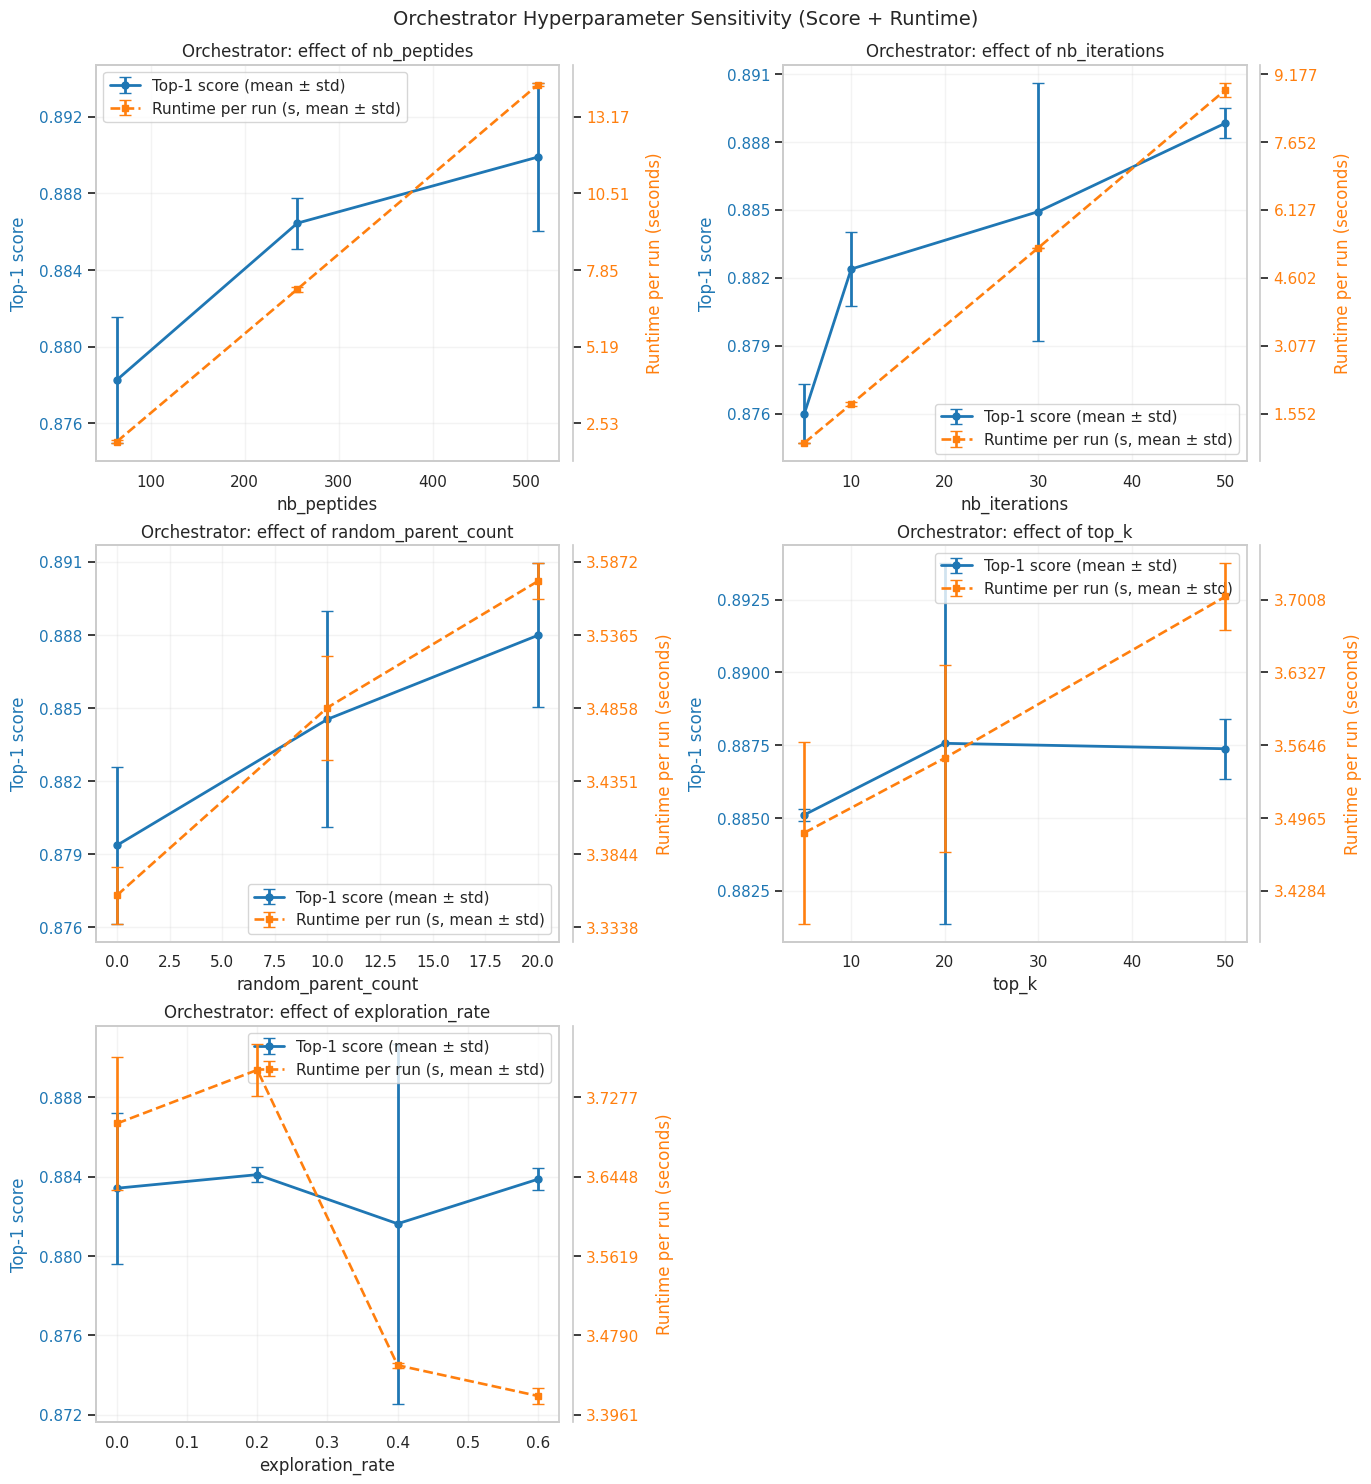

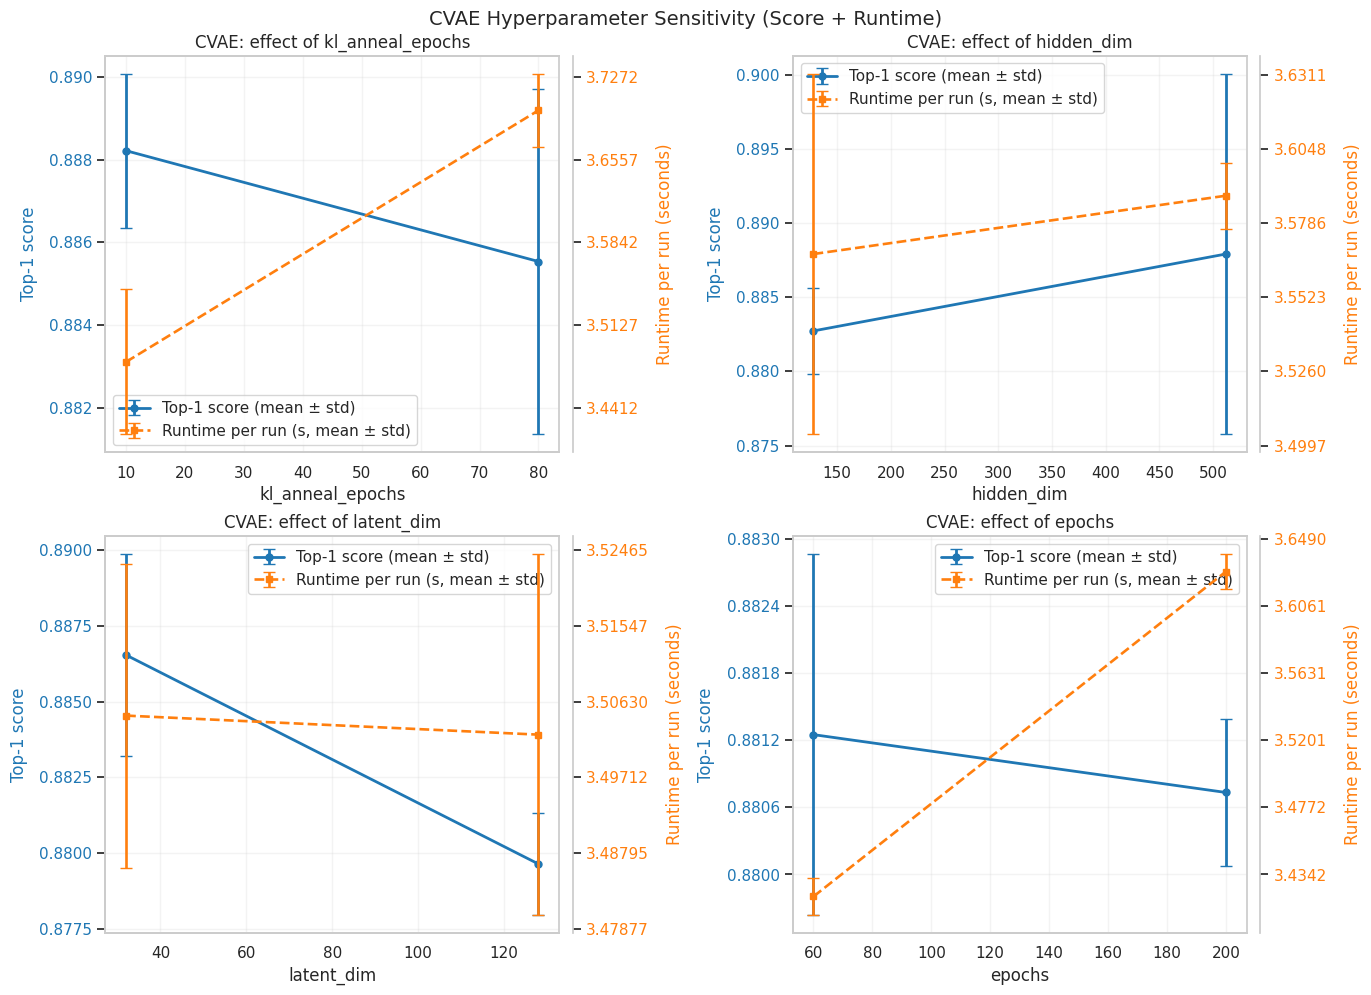

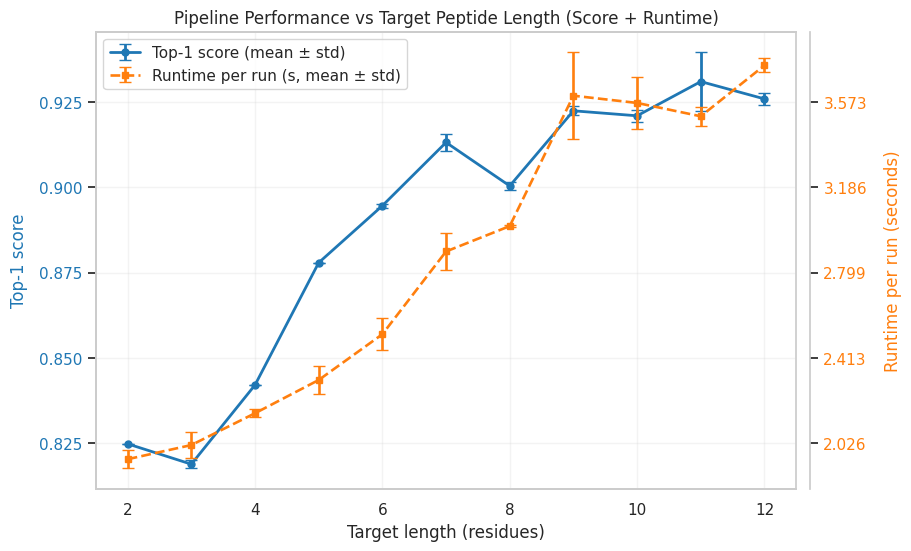

,method,top1_score_mean,top1_score_std,topk_mean_score_mean,topk_mean_score_std,validity_rate_mean,validity_rate_std,unique_ratio_mean,unique_ratio_std,mean_pairwise_distance_mean,mean_pairwise_distance_std,bigram_entropy_mean,bigram_entropy_std,elapsed_sec_mean,elapsed_sec_std
0,pipeline_reference,0.881329,0.004459,0.876514,0.003947,1.0,0.0,1.0,0.0,0.769697,0.011428,4.832624,0.098911,3.694326,0.048908


In [18]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
try:
    import seaborn as sns
    sns.set_theme(style="whitegrid")
except ImportError:
    print("Seaborn not found, falling back to matplotlib defaults.")
    plt.style.use('ggplot')


def align_dual_y_ticks(ax, ax2, n_ticks=6):
    # Force both y-axes to use the same number of major ticks.
    ax.yaxis.set_major_locator(MaxNLocator(nbins=n_ticks))
    ax2.yaxis.set_major_locator(MaxNLocator(nbins=n_ticks))

    # Recompute left ticks and map them to the right axis range so horizontal levels align.
    y1_ticks = ax.get_yticks()
    y1_min, y1_max = ax.get_ylim()
    y2_min, y2_max = ax2.get_ylim()

    if len(y1_ticks) > 1 and y1_max > y1_min:
        y2_ticks = np.interp(y1_ticks, [y1_min, y1_max], [y2_min, y2_max])

        # Keep alignment, but hide lowest/highest right-axis ticks for cleaner rendering.
        if len(y2_ticks) > 2:
            ax2.set_yticks(y2_ticks[1:-1])
        else:
            ax2.set_yticks(y2_ticks)


def style_dual_axis(ax, ax2):
    # Keep one shared grid from the left axis and force it behind the data.
    ax.grid(True, which='major', axis='both', alpha=0.22, zorder=0)
    ax.set_axisbelow(True)
    ax2.grid(False)

    # Reduce overlap between left/right y labels and ticks.
    ax.yaxis.labelpad = 8
    ax2.yaxis.labelpad = 12
    ax2.spines['right'].set_position(('outward', 10))

    # Align left/right horizontal levels.
    align_dual_y_ticks(ax, ax2, n_ticks=6)


def plot_single_parameter_sweep(df, param_name, ax=None):
    if df.empty:
        return
    subset = df[df['param_name'] == param_name].sort_values('param_value')
    if subset.empty:
        return

    try:
        subset['param_value'] = pd.to_numeric(subset['param_value'])
        subset = subset.sort_values('param_value')
    except Exception:
        pass

    if ax is None:
        _, ax = plt.subplots(figsize=(7.4, 4.8))

    ax2 = ax.twinx()

    # First line: quality
    h1 = ax.errorbar(
        subset['param_value'],
        subset['top1_score_mean'],
        yerr=subset['top1_score_std'].fillna(0.0),
        fmt='-o',
        capsize=4,
        color='tab:blue',
        linewidth=2.0,
        markersize=5,
        zorder=4,
        label='Top-1 score (mean ± std)',
    )
    ax.set_xlabel(param_name)
    ax.set_ylabel('Top-1 score', color='tab:blue')
    ax.tick_params(axis='y', labelcolor='tab:blue')

    # Second line: runtime
    h2 = ax2.errorbar(
        subset['param_value'],
        subset['elapsed_sec_mean'],
        yerr=subset['elapsed_sec_std'].fillna(0.0),
        fmt='--s',
        capsize=4,
        color='tab:orange',
        linewidth=1.9,
        markersize=5,
        zorder=5,
        label='Runtime per run (s, mean ± std)',
    )
    ax2.set_ylabel('Runtime per run (seconds)', color='tab:orange')
    ax2.tick_params(axis='y', labelcolor='tab:orange')

    style_dual_axis(ax, ax2)

    # Combined legend
    ax.legend([h1, h2], ['Top-1 score (mean ± std)', 'Runtime per run (s, mean ± std)'], loc='best')


# 1) Orchestrator one-at-a-time sensitivity with runtime cost
if 'orchestrator_results_df' in globals() and not orchestrator_results_df.empty:
    params = [p for p in orchestrator_results_df['param_name'].unique() if p != 'baseline']

    n_cols = 2
    n_rows = max(1, (len(params) + n_cols - 1) // n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(13.6, 4.8 * n_rows), constrained_layout=True)
    axes = np.array(axes).reshape(-1)

    for i, p in enumerate(params):
        plot_single_parameter_sweep(orchestrator_results_df, p, axes[i])
        axes[i].set_title(f'Orchestrator: effect of {p}')

    for j in range(len(params), len(axes)):
        axes[j].axis('off')

    fig.suptitle('Orchestrator Hyperparameter Sensitivity (Score + Runtime)', y=1.02, fontsize=14)
    plt.show()


# 2) CVAE one-at-a-time sensitivity with runtime cost
if 'cvae_results_df' in globals() and not cvae_results_df.empty:
    params = [p for p in cvae_results_df['param_name'].unique() if p != 'baseline']

    n_cols = 2
    n_rows = max(1, (len(params) + n_cols - 1) // n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(13.6, 4.8 * n_rows), constrained_layout=True)
    axes = np.array(axes).reshape(-1)

    for i, p in enumerate(params):
        plot_single_parameter_sweep(cvae_results_df, p, axes[i])
        axes[i].set_title(f'CVAE: effect of {p}')

    for j in range(len(params), len(axes)):
        axes[j].axis('off')

    fig.suptitle('CVAE Hyperparameter Sensitivity (Score + Runtime)', y=1.02, fontsize=14)
    plt.show()


# 3) Target length challenge (2..12): score + runtime
if 'length_sweep_summary_df' in globals() and not length_sweep_summary_df.empty:
    fig, ax = plt.subplots(figsize=(9.0, 5.4), constrained_layout=True)
    metrics = length_sweep_summary_df.sort_values('target_length').copy()

    ax2 = ax.twinx()

    h1 = ax.errorbar(
        metrics['target_length'],
        metrics['top1_score_mean'],
        yerr=metrics['top1_score_std'].fillna(0.0),
        fmt='-o',
        capsize=4,
        color='tab:blue',
        linewidth=2.0,
        markersize=5,
        zorder=4,
        label='Top-1 score (mean ± std)',
    )
    ax.set_xlabel('Target length (residues)')
    ax.set_ylabel('Top-1 score', color='tab:blue')
    ax.tick_params(axis='y', labelcolor='tab:blue')
    ax.set_title('Pipeline Performance vs Target Peptide Length (Score + Runtime)')

    h2 = ax2.errorbar(
        metrics['target_length'],
        metrics['elapsed_sec_mean'],
        yerr=metrics['elapsed_sec_std'].fillna(0.0),
        fmt='--s',
        capsize=4,
        color='tab:orange',
        linewidth=1.9,
        markersize=5,
        zorder=5,
        label='Runtime per run (s, mean ± std)',
    )
    ax2.set_ylabel('Runtime per run (seconds)', color='tab:orange')
    ax2.tick_params(axis='y', labelcolor='tab:orange')

    style_dual_axis(ax, ax2)
    ax.legend([h1, h2], ['Top-1 score (mean ± std)', 'Runtime per run (s, mean ± std)'], loc='best')

    plt.show()


# 4) Pipeline-only reference summary
if 'pipeline_reference_summary_df' in globals() and not pipeline_reference_summary_df.empty:
    display(pipeline_reference_summary_df)

In [13]:
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print('Cleanup done.')

Cleanup done.
